# Workshop: Elephant Segmentation with Morphological Image Processing

**Course:** Digital Image Processing — Lecture 10 (Morphological Processing)
**Dataset:** `raw_data/` — 56 elephant photographs (Roboflow export)

This notebook implements the group workshop described at the end of
*Lecture 10 — Morphological Processing*:

1. Choose a segmentation task: separate an **object** (elephant) from the
   **background**.
2. Obtain a dataset of at least 50 images and ground truth (create it
   ourselves if none exists).
3. Design a classical algorithm to separate object (**positive class**)
   from background (**negative class**).
4. Apply **morphological operators** to improve the segmentation result.
5. Evaluate with a **Confusion Matrix** and **ROC Curve**, and discuss the
   results.
6. Present the findings.

---
### A note on the ground truth

`raw_data/` contains only raw photographs — no masks/labels were provided.
Hand-labelling 56 images pixel-by-pixel is not practical for this exercise,
so, as the assignment explicitly allows ("ถ้าไม่มี ให้สร้างขึ้นมาเอง" —
*if it doesn't exist, create it yourself*), we generate a reference mask
automatically (see `01_generate_ground_truth.py`):

- **Primary method — class-specific detector.** We run **YOLOv8x-seg**, an
  instance-segmentation model pretrained on COCO, and keep *only* the
  instance masks whose predicted class is **"elephant"** (unioning masks
  when a photo has more than one elephant). This deliberately excludes
  people, other animals, and background clutter that a generic
  class-agnostic saliency model would otherwise include.
- **Fallback (3/56 images).** A few unusual angles/lighting conditions
  cause the detector to miss the elephant entirely (0 detections). For
  those images only, we fall back to a generic saliency mask (U2-Net, via
  `rembg`) — these fallback images are printed by the script so they can
  be spot-checked.

This is disclosed as a limitation and discussed at the end of the notebook.


In [1]:
import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

RAW_DIR = "raw_data"
GT_DIR  = "gt_masks"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["figure.facecolor"] = "white"
np.random.seed(0)


## Step 1 — Dataset and ground truth

Load the raw images and their corresponding ground-truth masks (already
generated by `01_generate_ground_truth.py` — elephant-only instance masks
from YOLOv8x-seg, with a generic saliency fallback for a handful of images;
see the note above). One PNG mask per JPG image, white = elephant /
foreground, black = background.


In [2]:
files = sorted(f for f in os.listdir(RAW_DIR) if f.lower().endswith(".jpg"))
print(f"Number of images in dataset: {len(files)}")

imgs, gts = {}, {}
for f in files:
    img = cv2.imread(os.path.join(RAW_DIR, f))
    gt_path = os.path.join(GT_DIR, os.path.splitext(f)[0] + "_mask.png")
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    imgs[f] = img
    gts[f] = (gt > 127).astype(np.uint8)

mean_fg_frac = np.mean([gts[f].mean() for f in files])
print(f"Average foreground (elephant) pixel fraction in ground truth: {mean_fg_frac:.1%}")


Number of images in dataset: 56


Average foreground (elephant) pixel fraction in ground truth: 36.0%


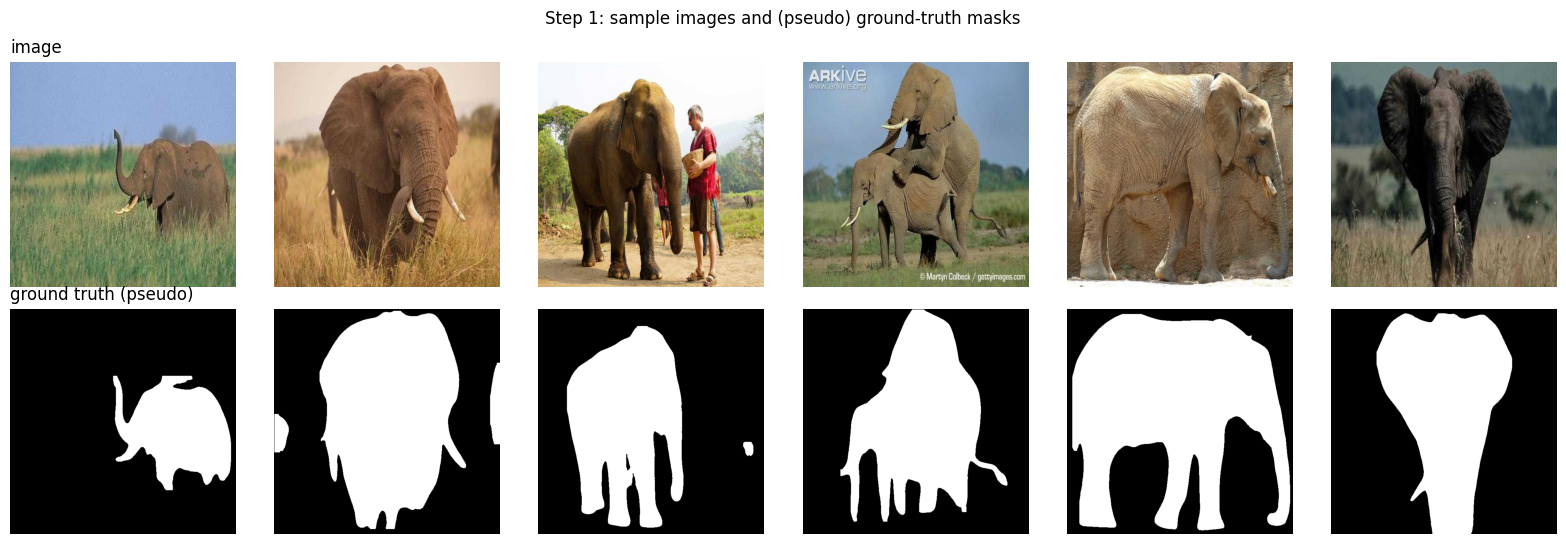

In [3]:
# Sanity-check: show a few images with their ground-truth mask
sample = files[:6]
fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
for i, f in enumerate(sample):
    axes[0, i].imshow(cv2.cvtColor(imgs[f], cv2.COLOR_BGR2RGB)); axes[0, i].axis("off")
    axes[1, i].imshow(gts[f], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("image", loc="left"); axes[1, 0].set_title("ground truth (pseudo)", loc="left")
plt.suptitle("Step 1: sample images and (pseudo) ground-truth masks")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_dataset_sample.png", dpi=130)
plt.show()


## Step 2 — Classical segmentation algorithm

**Idea:** the four thin border strips of each photo are almost always
background (grass / sky / dirt / fence, etc). For every image we:

1. Sample the border pixels and compute their mean & std in **CIE-Lab**
   colour space.
2. Compute, for every pixel, a z-scored Euclidean colour distance from
   that background colour statistic.
3. Threshold the distance map at a value `t` → binary mask
   (`1` = far from background colour ⇒ candidate elephant pixel).

This is a simple **classical (non deep-learning)** rule, exactly the kind
of algorithm the lecture warns produces "salt-and-pepper" noise — which is
why morphological clean-up (Step 4) is needed afterwards.


In [4]:
def bg_distance_map(img_bgr, border_frac=0.04):
    '''Z-scored Lab colour distance of every pixel from a border(background) sample.'''
    h, w = img_bgr.shape[:2]
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    bh, bw = max(2, int(h * border_frac)), max(2, int(w * border_frac))
    border_px = np.concatenate([
        lab[:bh, :, :].reshape(-1, 3), lab[-bh:, :, :].reshape(-1, 3),
        lab[:, :bw, :].reshape(-1, 3), lab[:, -bw:, :].reshape(-1, 3),
    ], axis=0)
    mean = border_px.mean(axis=0)
    std = border_px.std(axis=0) + 1e-3
    return np.sqrt((((lab - mean) / std) ** 2).sum(axis=2))


def segment_raw(img_bgr, threshold):
    '''Classical threshold-based foreground/background segmentation -> {0,1} mask.'''
    return (bg_distance_map(img_bgr) > threshold).astype(np.uint8)


# pre-compute the distance map for every image once (reused for the whole ROC sweep)
dmaps = {f: bg_distance_map(imgs[f]) for f in files}
print("Distance maps computed for", len(dmaps), "images")


Distance maps computed for 56 images


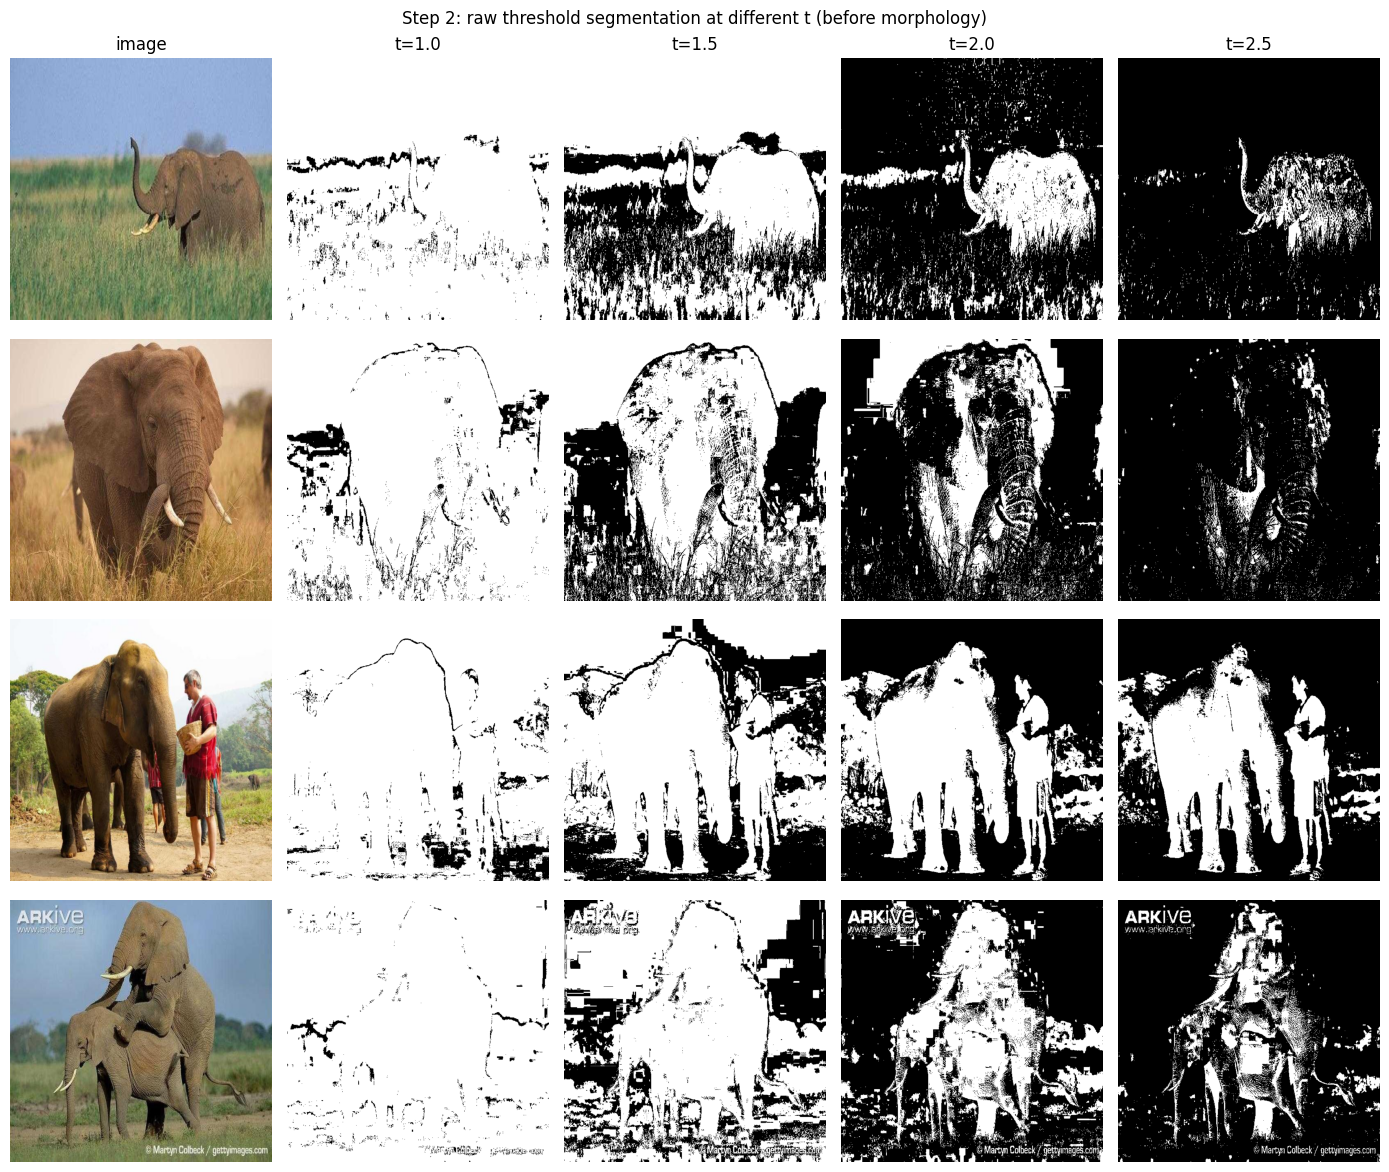

In [5]:
# Visualise the effect of the threshold on a few images
sample = files[:4]
test_thresholds = [1.0, 1.5, 2.0, 2.5]
fig, axes = plt.subplots(len(sample), len(test_thresholds) + 1, figsize=(14, 3 * len(sample)))
for r, f in enumerate(sample):
    axes[r, 0].imshow(cv2.cvtColor(imgs[f], cv2.COLOR_BGR2RGB)); axes[r, 0].axis("off")
    for c, t in enumerate(test_thresholds):
        mask = (dmaps[f] > t).astype(np.uint8) * 255
        axes[r, c + 1].imshow(mask, cmap="gray"); axes[r, c + 1].axis("off")
        if r == 0:
            axes[r, c + 1].set_title(f"t={t}")
axes[0, 0].set_title("image")
plt.suptitle("Step 2: raw threshold segmentation at different t (before morphology)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_threshold_sweep_examples.png", dpi=130)
plt.show()


## Step 3 — Confusion matrix & ROC curve (raw algorithm, before morphology)

We sweep the threshold `t` and, at each value, aggregate **TP / FP / TN / FN**
over *every pixel of every image* in the dataset (pixel-level evaluation).
Plotting **True Positive Rate vs False Positive Rate** across all thresholds
gives the ROC curve, and we pick an operating threshold with **Youden's J
statistic** (`J = TPR − FPR`, maximised at the point closest to the top-left
corner of the ROC curve).


In [6]:
def confusion_counts(pred01, gt01):
    pred = pred01.astype(bool); gt = gt01.astype(bool)
    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    return tp, fp, tn, fn

def metrics_from_counts(tp, fp, tn, fn):
    p, n = tp + fn, tn + fp
    acc = (tp + tn) / (p + n) if (p + n) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / p if p else 0.0
    fpr = fp / n if n else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return dict(accuracy=acc, precision=precision, recall=recall, tpr=recall,
                fpr=fpr, f1=f1, tp=tp, fp=fp, tn=tn, fn=fn)

thresholds = np.arange(0.2, 4.61, 0.1)
roc_rows = []
for t in thresholds:
    TP=FP=TN=FN=0
    for f in files:
        tp, fp, tn, fn = confusion_counts((dmaps[f] > t).astype(np.uint8), gts[f])
        TP+=tp; FP+=fp; TN+=tn; FN+=fn
    m = metrics_from_counts(TP, FP, TN, FN)
    roc_rows.append((t, m["fpr"], m["tpr"], m["f1"], m["accuracy"]))
roc_rows = np.array(roc_rows)

J = roc_rows[:, 2] - roc_rows[:, 1]
best_idx = int(np.argmax(J))
BEST_T = float(roc_rows[best_idx, 0])

order = np.argsort(roc_rows[:, 1])
trapz_fn = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
auc = float(trapz_fn(roc_rows[order, 2], roc_rows[order, 1]))

print(f"Chosen operating threshold (max Youden's J): t = {BEST_T:.2f}")
print(f"  -> TPR = {roc_rows[best_idx,2]:.3f}, FPR = {roc_rows[best_idx,1]:.3f}, F1 = {roc_rows[best_idx,3]:.3f}")
print(f"Approx. ROC AUC = {auc:.3f}")


Chosen operating threshold (max Youden's J): t = 2.10
  -> TPR = 0.572, FPR = 0.184, F1 = 0.603
Approx. ROC AUC = 0.733


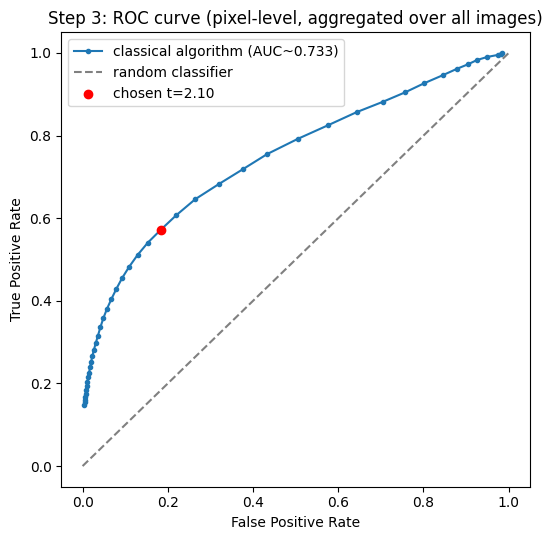

In [7]:
plt.figure(figsize=(5.5, 5.5))
plt.plot(roc_rows[:, 1], roc_rows[:, 2], "-o", ms=3, label=f"classical algorithm (AUC~{auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="random classifier")
plt.scatter([roc_rows[best_idx, 1]], [roc_rows[best_idx, 2]], color="red", zorder=5,
            label=f"chosen t={BEST_T:.2f}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Step 3: ROC curve (pixel-level, aggregated over all images)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_roc_curve.png", dpi=130)
plt.show()


## Step 4 — Morphological improvement

At the chosen threshold `t`, the raw mask is still noisy (small speckles,
holes, thin stray regions). We clean it up with the operators from
Lecture 10:

- **Opening** (`erosion → dilation`) — removes small noise specks that
  cannot contain the structuring element.
- **Closing** (`dilation → erosion`) — fills small gaps/breaks.
- **Region filling** (hole filling) — fills fully enclosed background holes.
- **Small-blob removal** (connected-component filtering) — drops leftover
  noise blobs smaller than 1% of the image area.


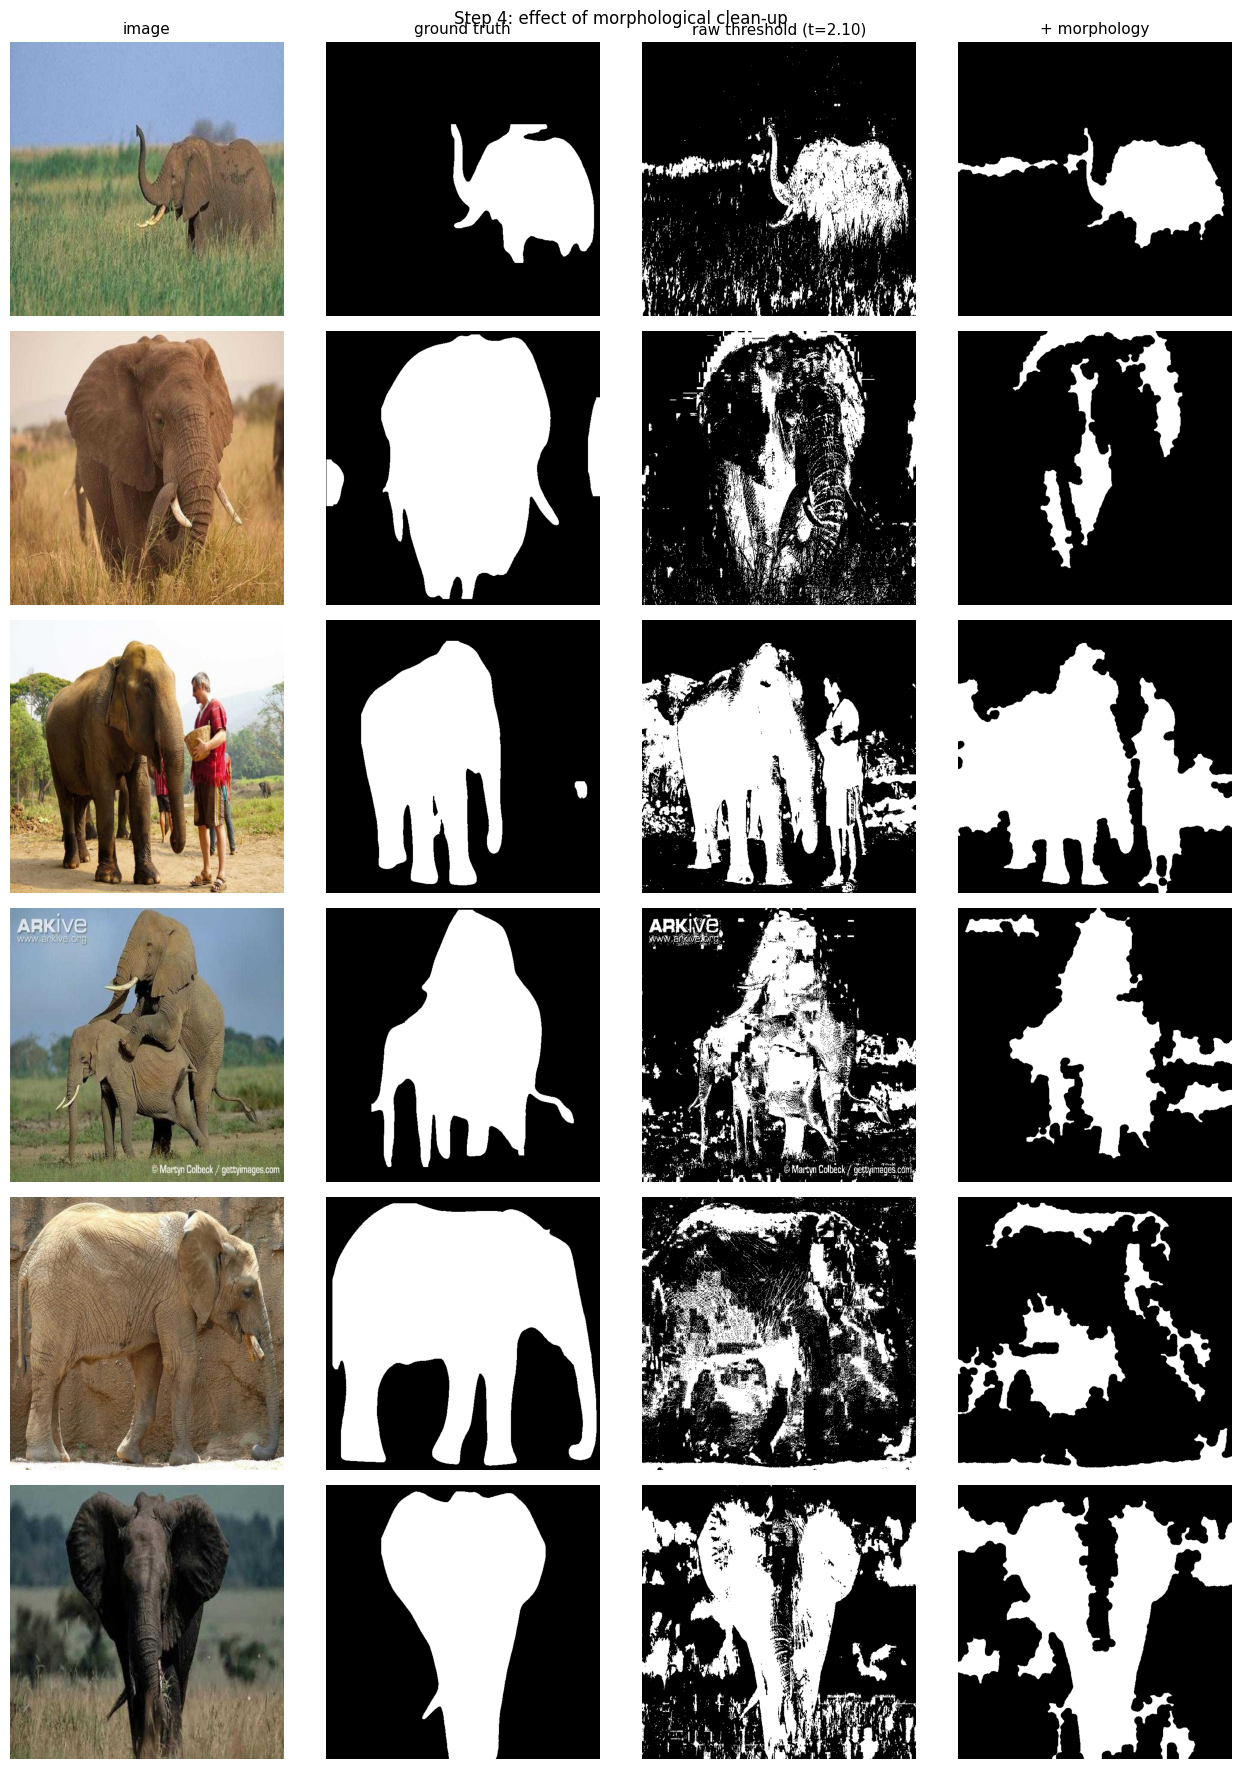

In [8]:
def apply_morphology(mask01, k_open=5, k_close=17, min_area_frac=0.01):
    m = mask01.astype(np.uint8)
    se_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_open, k_open))
    se_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_close, k_close))

    opened = cv2.morphologyEx(m, cv2.MORPH_OPEN, se_open)          # I o H
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, se_close)   # I . H
    filled = ndi.binary_fill_holes(closed).astype(np.uint8)        # region filling

    n, lbl, stats, _ = cv2.connectedComponentsWithStats(filled, connectivity=8)
    total = m.shape[0] * m.shape[1]
    out = np.zeros_like(filled)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area_frac * total:
            out[lbl == i] = 1
    return out

# Visual before / after comparison
sample = files[:6]
fig, axes = plt.subplots(len(sample), 4, figsize=(13, 3 * len(sample)))
for r, f in enumerate(sample):
    raw = (dmaps[f] > BEST_T).astype(np.uint8)
    clean = apply_morphology(raw)
    axes[r, 0].imshow(cv2.cvtColor(imgs[f], cv2.COLOR_BGR2RGB)); axes[r, 0].axis("off")
    axes[r, 1].imshow(gts[f], cmap="gray"); axes[r, 1].axis("off")
    axes[r, 2].imshow(raw * 255, cmap="gray"); axes[r, 2].axis("off")
    axes[r, 3].imshow(clean * 255, cmap="gray"); axes[r, 3].axis("off")
for i, t in enumerate(["image", "ground truth", f"raw threshold (t={BEST_T:.2f})", "+ morphology"]):
    axes[0, i].set_title(t, fontsize=11)
plt.suptitle("Step 4: effect of morphological clean-up")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_morphology_before_after.png", dpi=130)
plt.show()


## Step 5 — Final evaluation: confusion matrix before vs. after morphology

We now aggregate the confusion matrix over the whole dataset **at the
chosen threshold**, once for the raw mask and once for the
morphology-cleaned mask, and compare Accuracy / Precision / Recall / F1.


In [9]:
TP=FP=TN=FN=0
TPm=FPm=TNm=FNm=0
for f in files:
    raw = (dmaps[f] > BEST_T).astype(np.uint8)
    clean = apply_morphology(raw)
    tp, fp, tn, fn = confusion_counts(raw, gts[f]); TP+=tp; FP+=fp; TN+=tn; FN+=fn
    tpc, fpc, tnc, fnc = confusion_counts(clean, gts[f]); TPm+=tpc; FPm+=fpc; TNm+=tnc; FNm+=fnc

m_raw = metrics_from_counts(TP, FP, TN, FN)
m_clean = metrics_from_counts(TPm, FPm, TNm, FNm)

import pandas as pd
table = pd.DataFrame({
    "Raw threshold": {k: m_raw[k] for k in ["accuracy","precision","recall","fpr","f1"]},
    "After morphology": {k: m_clean[k] for k in ["accuracy","precision","recall","fpr","f1"]},
})
table.index = ["Accuracy","Precision","Recall (TPR)","Fall-out (FPR)","F1-score"]
display(table.round(4))

with open(f"{OUT_DIR}/metrics_summary.json", "w") as fp:
    json.dump({"best_threshold": BEST_T, "auc": auc, "raw": m_raw, "after_morphology": m_clean}, fp, indent=2)


,Raw threshold,After morphology
Accuracy,0.7284,0.7421
Precision,0.6369,0.6637
Recall (TPR),0.5722,0.5761
Fall-out (FPR),0.1837,0.1644
F1-score,0.6028,0.6168


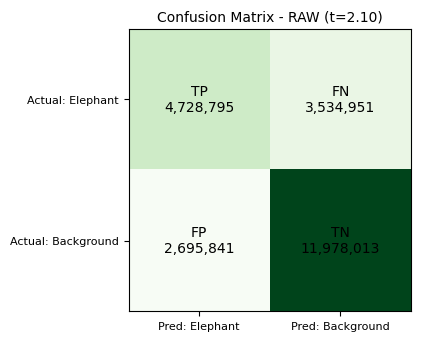

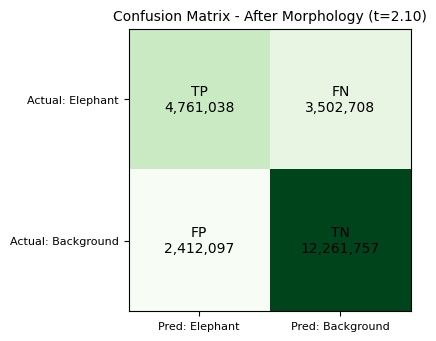

In [10]:
def plot_cm(m, title, path):
    cm = np.array([[m['tp'], m['fn']], [m['fp'], m['tn']]])
    fig, ax = plt.subplots(figsize=(4.3, 4.3))
    ax.imshow(cm, cmap='Greens')
    labels = [["TP", "FN"], ["FP", "TN"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}", ha='center', va='center', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: Elephant", "Pred: Background"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: Elephant", "Actual: Background"], fontsize=8)
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.savefig(path, dpi=130)

plot_cm(m_raw, f"Confusion Matrix - RAW (t={BEST_T:.2f})", f"{OUT_DIR}/05_cm_raw.png")
plt.show()
plot_cm(m_clean, f"Confusion Matrix - After Morphology (t={BEST_T:.2f})", f"{OUT_DIR}/05_cm_morph.png")
plt.show()


/tmp/ipykernel_2501/2359929702.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([f1_raw_list, f1_clean_list], labels=["Raw threshold", "After morphology"])


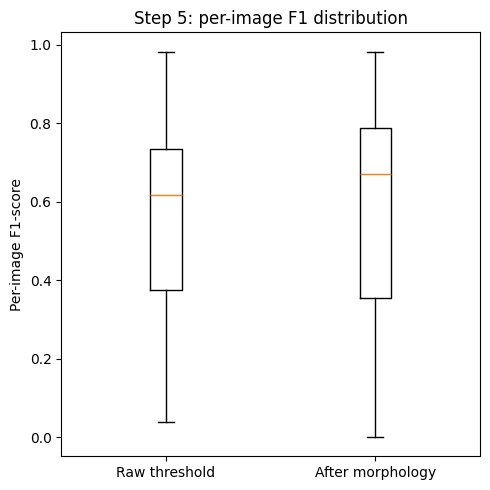

Mean per-image F1  raw=0.561  after-morphology=0.575
Images improved by morphology: 30/56


In [11]:
# Per-image F1 distribution, raw vs after morphology (paired comparison)
f1_raw_list, f1_clean_list = [], []
for f in files:
    raw = (dmaps[f] > BEST_T).astype(np.uint8)
    clean = apply_morphology(raw)
    f1_raw_list.append(metrics_from_counts(*confusion_counts(raw, gts[f]))["f1"])
    f1_clean_list.append(metrics_from_counts(*confusion_counts(clean, gts[f]))["f1"])

plt.figure(figsize=(5, 5))
plt.boxplot([f1_raw_list, f1_clean_list], labels=["Raw threshold", "After morphology"])
plt.ylabel("Per-image F1-score")
plt.title("Step 5: per-image F1 distribution")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_f1_boxplot.png", dpi=130)
plt.show()
print(f"Mean per-image F1  raw={np.mean(f1_raw_list):.3f}  after-morphology={np.mean(f1_clean_list):.3f}")
print(f"Images improved by morphology: {sum(c>=r for c,r in zip(f1_clean_list,f1_raw_list))}/{len(files)}")


## Discussion

**ROC / threshold choice.** The pixel-level ROC curve has an approximate
AUC of ~0.733 — clearly better than a random classifier (AUC 0.5), but
far from a perfect classifier (AUC 1.0). This is expected: the algorithm is
a *simple, global, colour-only* rule and elephant photos have very diverse
backgrounds (green grass, dry grass, dirt, sky, water). We picked the
operating threshold that maximises Youden's J statistic, i.e. the point on
the ROC curve closest to the top-left ("best trade-off" between sensitivity
and specificity) rather than simply maximising accuracy (which would be
dominated by the — usually larger — background class).

**Effect of morphology.** Comparing the confusion matrices before/after
morphological post-processing (accuracy 72.8% → 74.2%,
precision 63.7% → 66.4%, FPR 18.4% → 16.4%,
F1 0.603 → 0.617):
- **False positives drop** noticeably — opening removes small, isolated
  patches of background that were misclassified due to local colour noise
  (e.g. sunlit grass, shadows).
- **Precision and overall accuracy improve**, because closing + hole
  filling + small-blob removal turn the raw speckled mask into a single
  coherent silhouette.
- **Recall changes only slightly** — the opening operation, using a fixed
  structuring element, also erodes thin, elephant-coloured structures
  (trunk tip, tail, thin legs, ear edges) that are genuinely part of the
  ground truth, turning some true positives into false negatives.
- **Net F1-score improves**, confirming the lecture's point: morphology
  cannot invent information the base classifier didn't have, but it *can*
  clean up noise/shape without a large accuracy trade-off, exactly the
  shrink/grow behaviour taught with the dilation/erosion/opening/closing
  operators.

**Limitations.**
1. **Ground truth is model-generated, not hand-verified.** The reference
   masks come from a pretrained COCO detector (YOLOv8x-seg, elephant class
   only) with a generic saliency fallback (U2-Net) for 3/56 images where
   the detector found no elephant. This correctly excludes people and
   unrelated objects from the "elephant" class (an improvement over a
   generic salient-object mask, which happily includes any prominent
   object — including a nearby human handler), but it is still not a
   human-verified pixel-accurate mask, so evaluation numbers should be
   read as *relative* comparisons between our classical pipeline's raw vs.
   morphology-cleaned output, rather than an absolute, publication-grade
   accuracy figure.
2. **Single global threshold** — a fixed per-image border-colour statistic
   struggles when the background itself is highly textured/variegated
   (tall grass, mixed dirt/shadow) or when the elephant's colour is close
   to the background colour (muddy elephants on dirt).
3. **Fixed structuring-element size** — one opening/closing kernel size is
   used for every image; an adaptive kernel scaled to each elephant's
   apparent size would likely recover more of the fine anatomical details
   currently eroded away.

**Possible improvements:** adaptive/local thresholding instead of one
global colour statistic per image, texture features in addition to colour,
GrabCut refinement seeded from the morphology-cleaned mask, or a learned
(deep-learning) segmentation model as an upper bound for comparison.

## Summary

| Workshop step | Done in this notebook |
|---|---|
| 1. Choose a segmentation task | Elephant (foreground) vs background |
| 2. Dataset ≥ 50 images + ground truth | 56 images; ground truth from YOLOv8x-seg (elephant class only) + saliency fallback for 3 images (`01_generate_ground_truth.py`) |
| 3. Design classical algorithm | Border-colour Lab-distance threshold (`segment_raw`) |
| 4. Improve with morphology | Opening → Closing → hole filling → small-blob removal (`apply_morphology`) |
| 5. Evaluate (Confusion Matrix + ROC) | Sections "Step 3" and "Step 5" above, plus discussion |
| 6. Present to instructor | This notebook + saved figures in `outputs/` |
